In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import time
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# Load dataset
dataset_path = "/kaggle/input/diseases-and-symptoms-dataset/Final_Augmented_dataset_Diseases_and_Symptoms.csv"
df = pd.read_csv(dataset_path)

In [4]:
# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['diseases'])

In [5]:
# Convert symptom columns to description
df['text_description'] = df.drop(columns=['diseases', 'label']).apply(lambda row: ' '.join(row.index[row == 1]), axis=1)

In [6]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(df['text_description'], df['label'], test_size=0.2, random_state=42)

In [7]:
# Load tokenizers
xlnet_tokenizer = AutoTokenizer.from_pretrained("xlnet-base-cased")
electra_tokenizer = AutoTokenizer.from_pretrained("google/electra-base-discriminator")

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.38M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/666 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [8]:
from torch.utils.data import Dataset
import torch

class SymptomHybridDataset(Dataset):
    def __init__(self, texts, labels, xlnet_tokenizer, electra_tokenizer, max_length=128):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.xlnet_tokenizer = xlnet_tokenizer
        self.electra_tokenizer = electra_tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        xlnet_encoding = self.xlnet_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        electra_encoding = self.electra_tokenizer(
            self.texts[idx], truncation=True, padding="max_length",
            max_length=self.max_length, return_tensors="pt"
        )
        return {
            "xlnet": {k: v.squeeze(0) for k, v in xlnet_encoding.items()},
            "electra": {k: v.squeeze(0) for k, v in electra_encoding.items()},
            "label": torch.tensor(self.labels[idx], dtype=torch.long)
        }

In [9]:
# Data loaders
train_dataset = SymptomHybridDataset(X_train, y_train, xlnet_tokenizer, electra_tokenizer)
test_dataset = SymptomHybridDataset(X_test, y_test, xlnet_tokenizer, electra_tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [10]:
import torch
import torch.nn as nn
from transformers import AutoModel

class XLNet_ELECTRA_Classifier(nn.Module):
    def __init__(self, num_labels):  # ✅ Use double underscores
        super(XLNet_ELECTRA_Classifier, self).__init__()  # ✅ Use double underscores
        self.xlnet = AutoModel.from_pretrained("xlnet-base-cased")
        self.electra = AutoModel.from_pretrained("google/electra-base-discriminator")
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(768 * 2, num_labels)

    def forward(self, xlnet_inputs, electra_inputs):
        xlnet_output = self.xlnet(**xlnet_inputs).last_hidden_state[:, -1, :]  # Last token
        electra_output = self.electra(**electra_inputs).last_hidden_state[:, 0, :]  # [CLS] token
        combined = torch.cat((xlnet_output, electra_output), dim=1)
        out = self.dropout(combined)
        return self.classifier(out)

In [11]:
# Initialize model
model = XLNet_ELECTRA_Classifier(num_labels=len(label_encoder.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=2e-5)

2025-05-29 08:01:37.754404: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748505697.926721      75 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748505697.979777      75 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


pytorch_model.bin:   0%|          | 0.00/467M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/467M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [12]:
# Training loop (training only — no test eval here)
num_epochs = 4
train_loss_values, train_accuracies = [], []
start_time = time.time()

for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    correct_train, total_train = 0, 0

    for batch in train_loader:
        optimizer.zero_grad()
        xlnet_inputs = {k: v.to(device) for k, v in batch["xlnet"].items()}
        electra_inputs = {k: v.to(device) for k, v in batch["electra"].items()}
        labels = batch["label"].to(device)

        outputs = model(xlnet_inputs, electra_inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        predictions = torch.argmax(outputs, dim=1)
        correct_train += (predictions == labels).sum().item()
        total_train += labels.size(0)

    avg_train_loss = total_train_loss / len(train_loader)
    train_accuracy = correct_train / total_train

    train_loss_values.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Train Acc = {train_accuracy:.4f}")

end_time = time.time()
print(f"\nTotal Training Time: {end_time - start_time:.2f} seconds")

Epoch 1: Train Loss = 1.2948, Train Acc = 0.6991
Epoch 2: Train Loss = 0.5712, Train Acc = 0.8253
Epoch 3: Train Loss = 0.4976, Train Acc = 0.8386
Epoch 4: Train Loss = 0.4616, Train Acc = 0.8458

Total Training Time: 40911.62 seconds


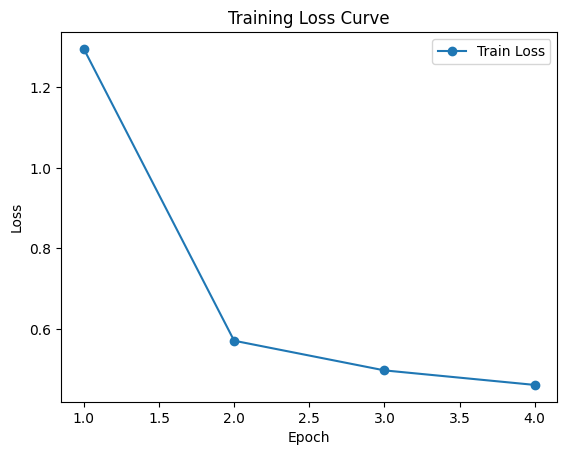

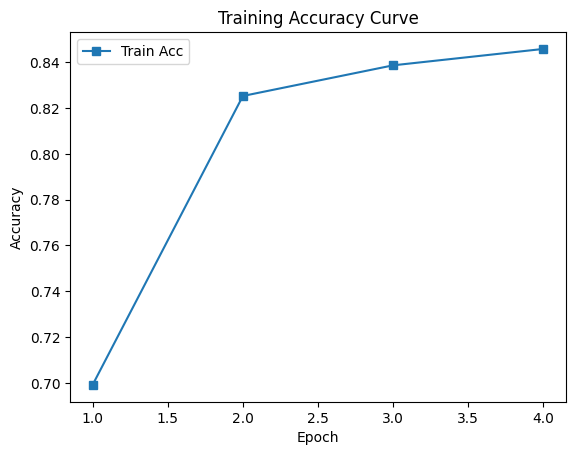

In [13]:
# Plotting training metrics
plt.plot(range(1, num_epochs+1), train_loss_values, marker='o', label='Train Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.show()

plt.plot(range(1, num_epochs+1), train_accuracies, marker='s', label='Train Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.legend()
plt.show()

In [14]:
# Final evaluation on test set
y_true, y_pred = [], []
model.eval()
with torch.no_grad():
    for batch in test_loader:
        xlnet_inputs = {k: v.to(device) for k, v in batch["xlnet"].items()}
        electra_inputs = {k: v.to(device) for k, v in batch["electra"].items()}
        labels = batch["label"].to(device)

        outputs = model(xlnet_inputs, electra_inputs)
        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predictions.cpu().numpy())

print("\nClassification Report:")
print(classification_report(
    y_true, y_pred,
    labels=np.arange(len(label_encoder.classes_)),
    target_names=label_encoder.classes_
))


Classification Report:
                                                          precision    recall  f1-score   support

                               abdominal aortic aneurysm       1.00      1.00      1.00        20
                                        abdominal hernia       0.94      0.95      0.94        81
                                         abscess of nose       0.88      0.88      0.88        58
                                     abscess of the lung       1.00      1.00      1.00         6
                                  abscess of the pharynx       0.82      0.97      0.89        63
                                    acanthosis nigricans       0.75      0.50      0.60         6
                                               acariasis       1.00      1.00      1.00         5
                                               achalasia       0.75      0.90      0.82        20
                                                    acne       0.99      0.68      0.80      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.